In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Tensorflow version:", tf.__version__)

Tensorflow version: 2.21.0


In [2]:
df = pd.read_csv('Concrete_Data.csv')

In [3]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.columns = [
    'cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'strength'
]

In [5]:
df.head()

,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
print('Shape of the datasetL', df.shape)

Shape of the datasetL (1030, 9)


In [7]:
print('Columns:', list(df.columns))

Columns: ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'strength']


In [8]:
df.dtypes

cement              float64
slag                float64
fly_ash             float64
water               float64
superplasticizer    float64
coarse_agg          float64
fine_agg            float64
age                   int64
strength            float64
dtype: object

In [9]:
# Missing values
df.isna().sum()

cement              0
slag                0
fly_ash             0
water               0
superplasticizer    0
coarse_agg          0
fine_agg            0
age                 0
strength            0
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
fly_ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
coarse_agg,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
fine_agg,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


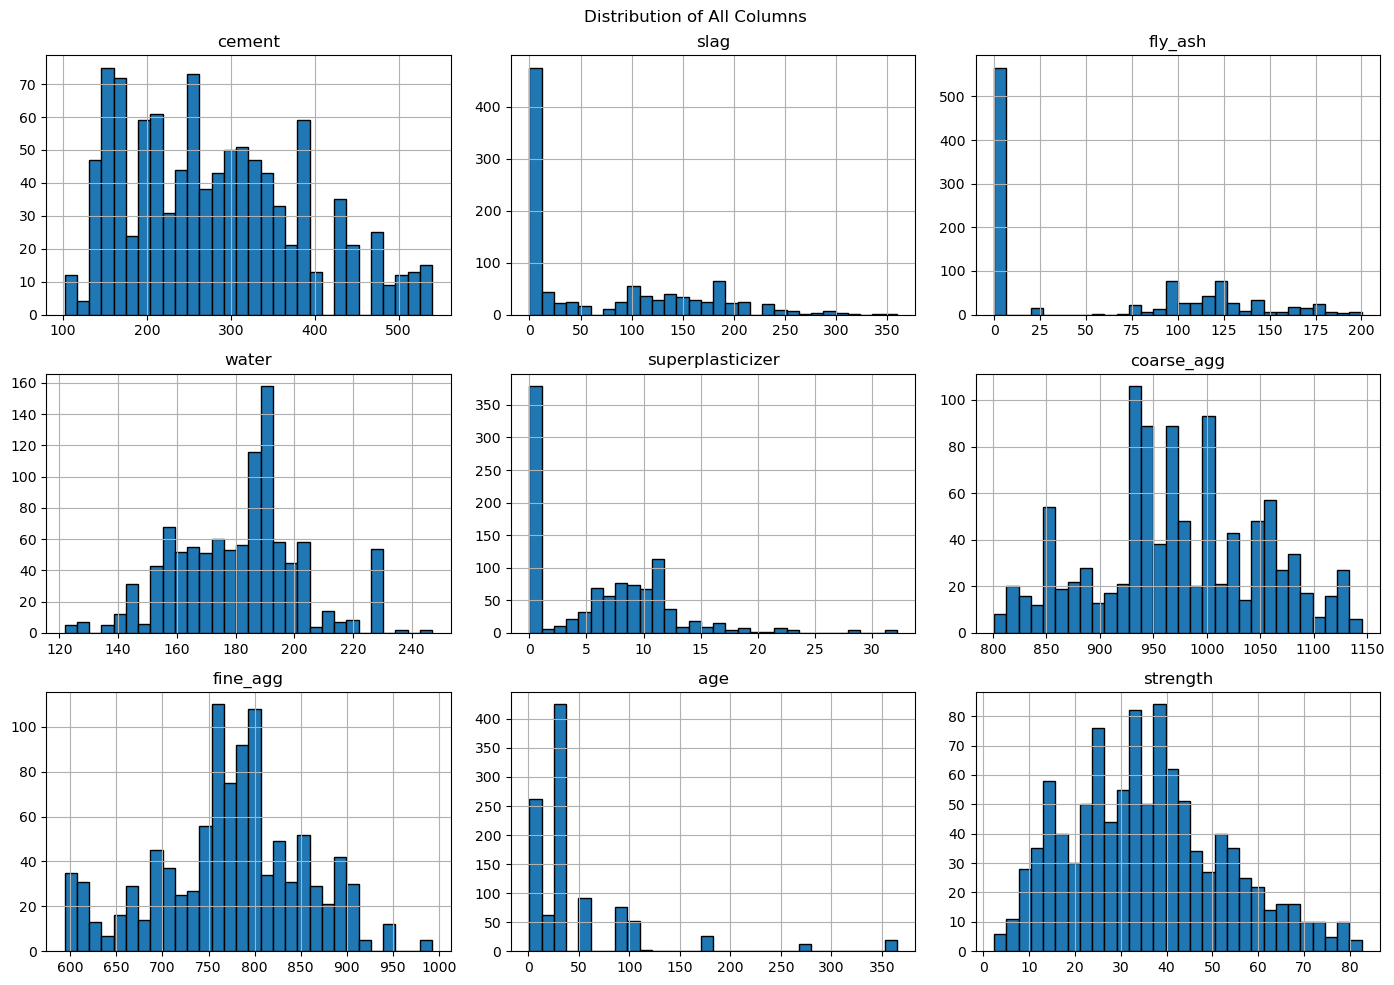

In [12]:
df.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of All Columns')
plt.tight_layout()
plt.show()

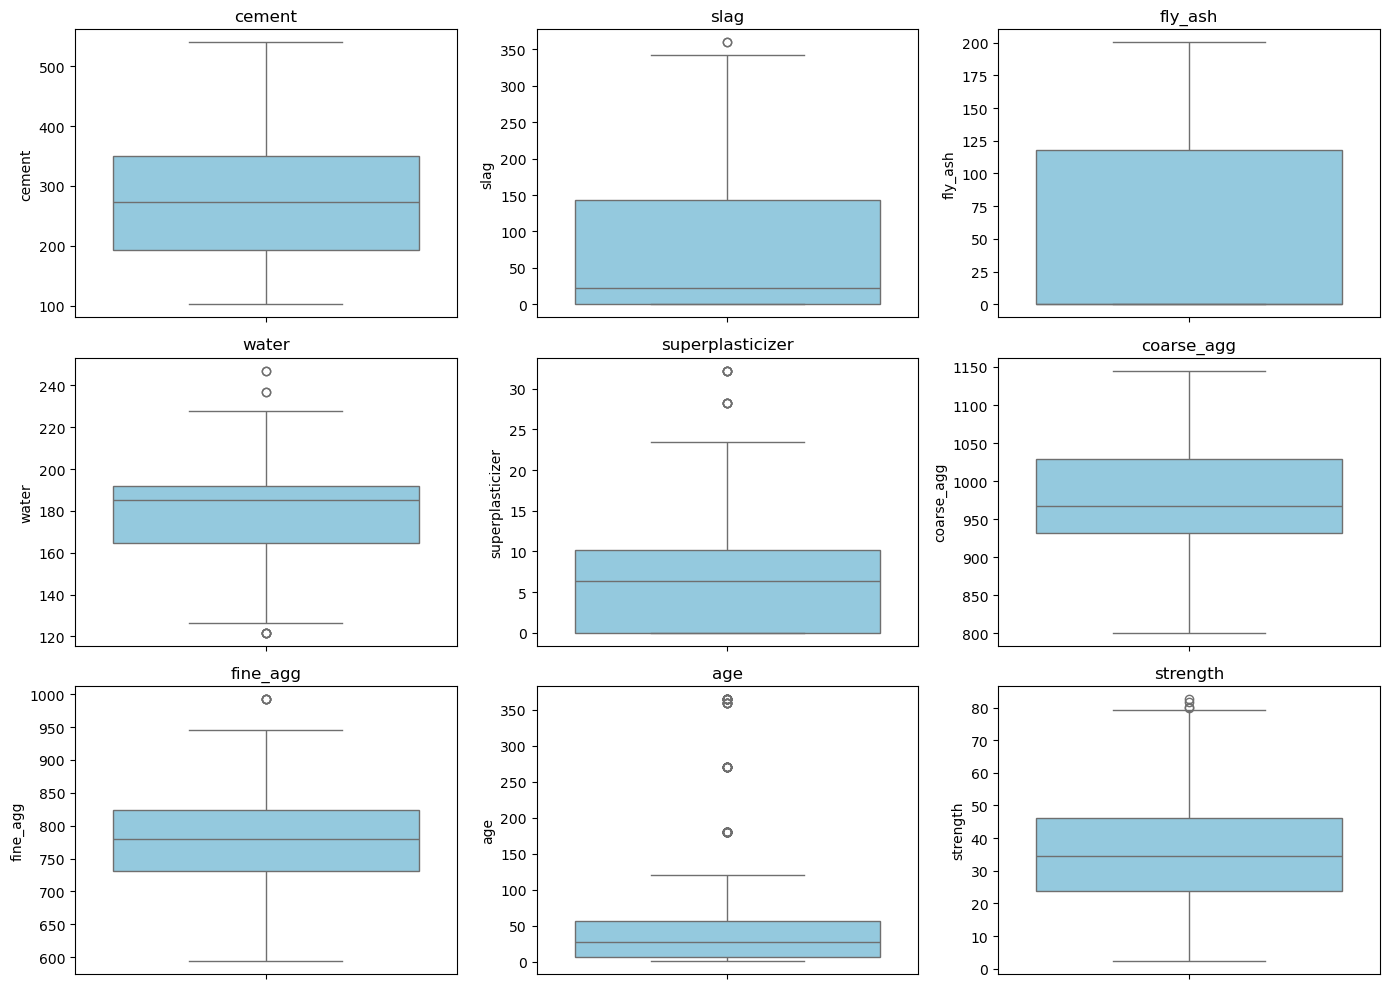

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

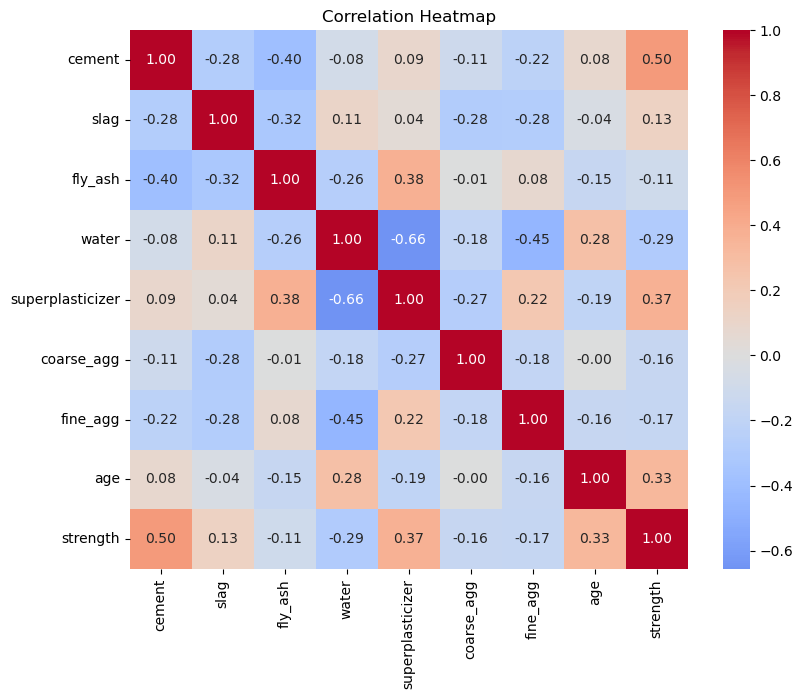

In [15]:
plt.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

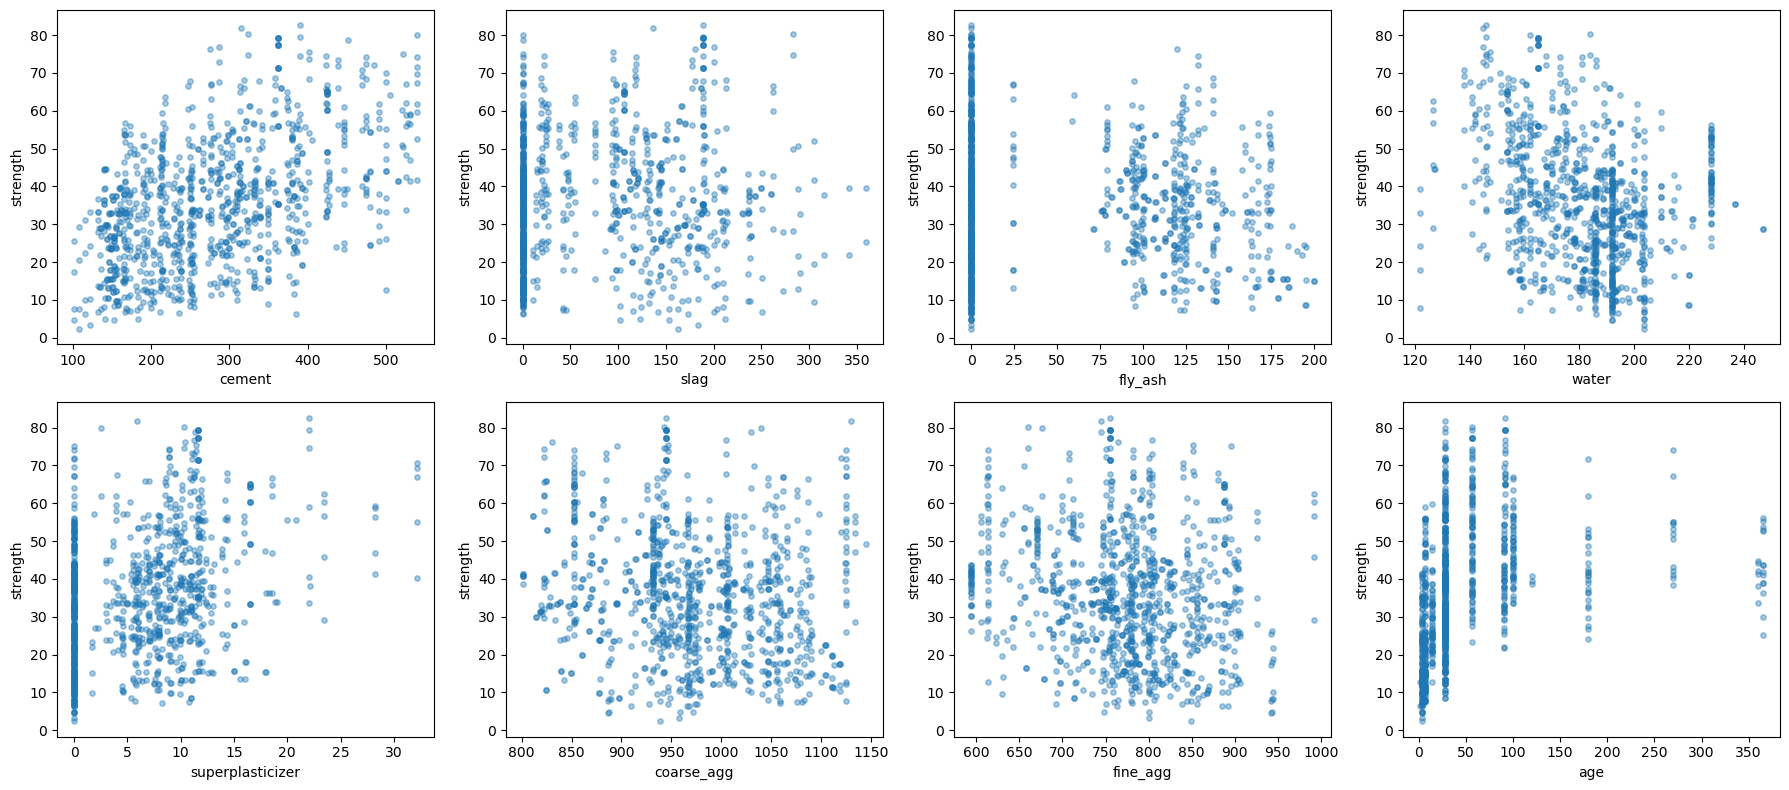

In [16]:
features = df.columns[:-1]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df['strength'], alpha=0.4, s=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('strength')
plt.tight_layout()
plt.show()

In [17]:
X = df.drop(columns=['strength'])
y = df['strength']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1030, 8)
y shape: (1030,)


In [18]:
X

,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [19]:
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: strength, Length: 1030, dtype: float64

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

In [25]:
print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 824
Testing samples: 206


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training data mean after scaling', X_train_scaled.mean(axis=0).round(2))
print('Training data std after scaling', X_train_scaled.std(axis=0).round(2))

Training data mean after scaling [ 0.  0.  0.  0. -0.  0. -0. -0.]
Training data std after scaling [1. 1. 1. 1. 1. 1. 1. 1.]


In [27]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lr = lin_reg.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression -- MAE : {mae_lr:.3f} | MSE: {mse_lr:.3f} | RMSE : {rmse_lr:.3f} | R2 : {r2_lr:.3f}")

Linear Regression -- MAE : 7.746 | MSE: 95.971 | RMSE : 9.796 | R2 : 0.628


In [31]:
def build_model(hidden_units=(32, 16), learning_rate=0.001, dropout_rate=0.0, input_dim=8):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))


    model.add(layers.Dense(1, activation='linear'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )

    return model

baseline_ann = build_model()
baseline_ann.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = baseline_ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    verbose=0
)

print('Final training MAE :', round(history.history['mae'][-1],3))
print('Final validation MAE :', round(history.history['val_mae'][-1],3))

Final training MAE : 4.412
Final validation MAE : 4.602


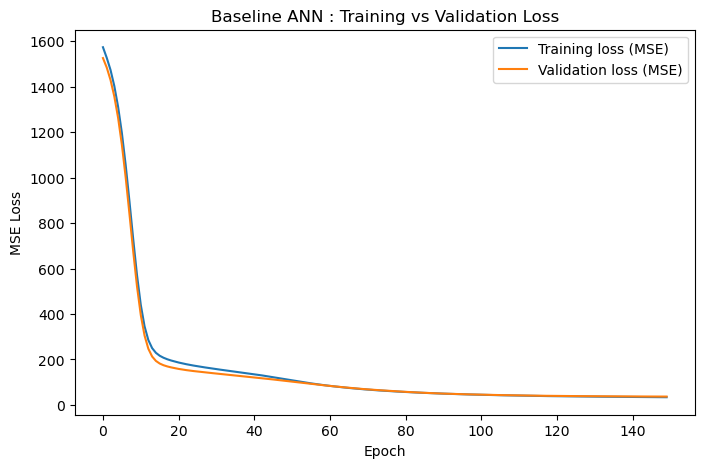

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Baseline ANN : Training vs Validation Loss')
plt.legend()
plt.show()

In [35]:
variants = {
    'A. Baseline (32, 16)': dict(hidden_units=(32, 16), learning_rate=0.001, dropout_rate=0.0),
    'B. Deeper (64, 32, 16)': dict(hidden_units=(64, 32, 16), learning_rate=0.001, dropout_rate=0.0),
    'C. lower LR (64, 32, 16)': dict(hidden_units=(64, 32, 16), learning_rate=0.0005, dropout_rate=0.0),
    'D. Dropout (64, 32, 16)': dict(hidden_units=(64, 32, 16), learning_rate=0.001, dropout_rate=0.2)
}

results = {}
histories = {}

for name, params in variants.items():
    tf.random.set_seed(SEED)
    m = build_model(**params)
    h = m.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=150,
        batch_size=32,
        verbose=0
    )

    val_mae = h.history['val_mae'][-1]
    results[name] = val_mae
    histories[name] = h
    print(f"{name} --> final validation: {val_mae:.3f}")

A. Baseline (32, 16) --> final validation: 5.420
B. Deeper (64, 32, 16) --> final validation: 4.160
C. lower LR (64, 32, 16) --> final validation: 4.529
D. Dropout (64, 32, 16) --> final validation: 5.597


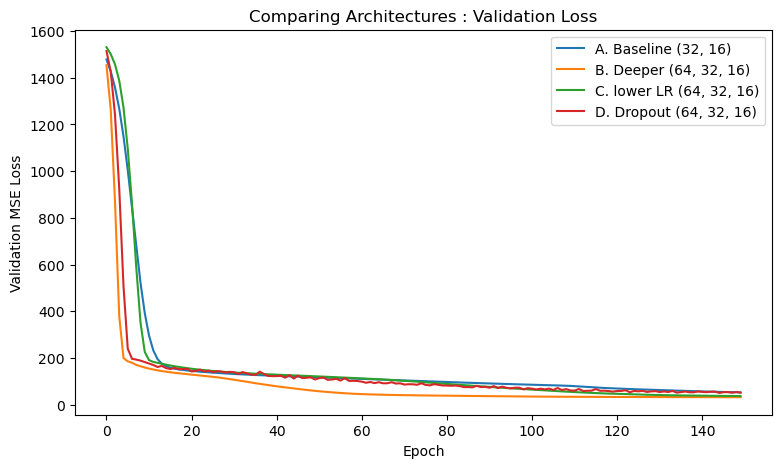

Best variant on validation MAE: B. Deeper (64, 32, 16)


In [36]:
plt.figure(figsize=(9, 5))
for name, h in histories.items():
    plt.plot(h.history['val_loss'], label=name)

plt.xlabel('Epoch')
plt.ylabel('Validation MSE Loss')
plt.title('Comparing Architectures : Validation Loss')
plt.legend()
plt.show()

best_variant = min(results, key=results.get)
print('Best variant on validation MAE:', best_variant)

In [37]:
final_params = variants[best_variant]
tf.random.set_seed(SEED)
final_ann = build_model(**final_params)

final_history = final_ann.fit(
    X_train_scaled, y_train,
    validation_split = 0.2,
    epochs=200,
    batch_size=32,
    verbose=0
)
print('Final model trained using configuration:', final_params)

Final model trained using configuration: {'hidden_units': (64, 32, 16), 'learning_rate': 0.001, 'dropout_rate': 0.0}


In [38]:
y_pred_ann = final_ann.predict(X_test_scaled, verbose=0).flatten()

mae_ann = mean_absolute_error(y_test, y_pred_ann)
mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test, y_pred_ann)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'ANN'],
    'MAE' : [mae_lr, mae_ann],
    'MSE' : [mse_lr, mse_ann],
    'RMSE' : [rmse_lr, rmse_ann],
    'R2' : [r2_lr, r2_ann]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,7.745559,95.970940,9.796476,0.627553
1,ANN,4.439917,40.465575,6.361256,0.842960


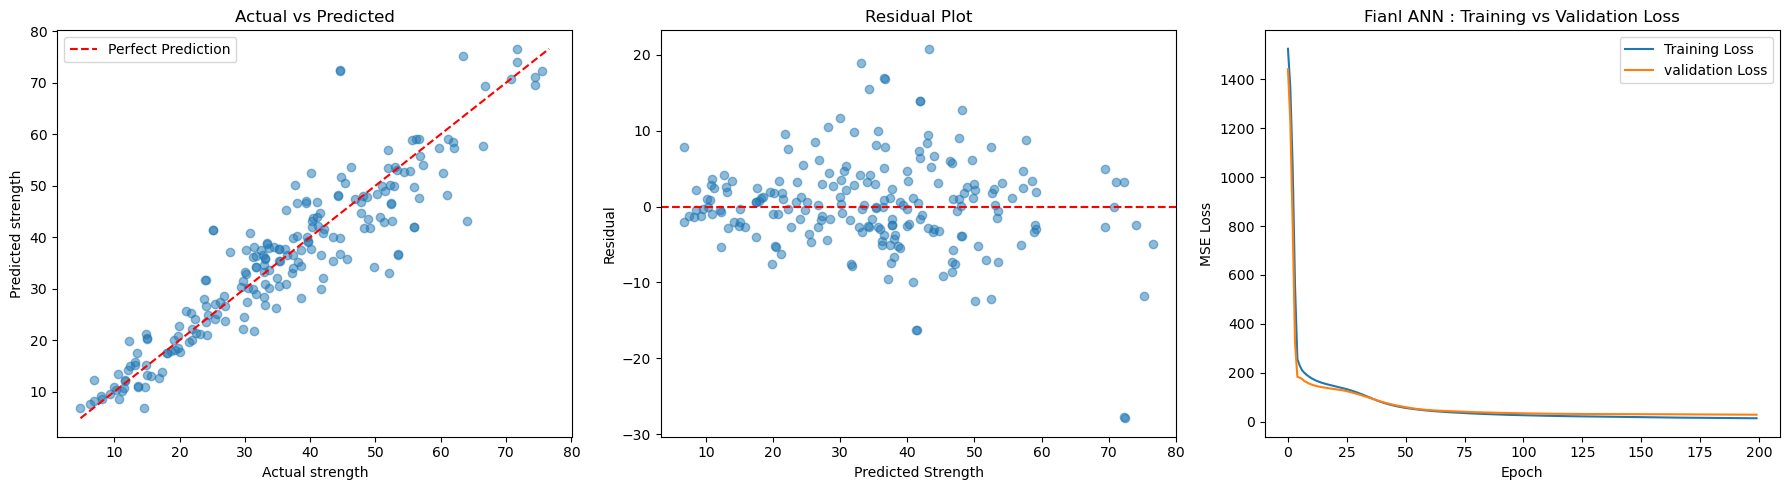

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_test, y_pred_ann, alpha=0.5)
lims = [min(y_test.min(), y_pred_ann.min()), max(y_test.max(), y_pred_ann.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual strength')
axes[0].set_ylabel('Predicted strength')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

residuals = y_test.values - y_pred_ann
axes[1].scatter(y_pred_ann, residuals, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Strength')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

axes[2].plot(final_history.history['loss'], label='Training Loss')
axes[2].plot(final_history.history['val_loss'], label='validation Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('Fianl ANN : Training vs Validation Loss')
axes[2].legend()

plt.tight_layout()
plt.show()